# 4. Класифікатор Decision Tree (Дерево рішень)

Дерево рішень --- це алгоритм класифікації, який рекурсивно розбиває дані на підмножини за допомогою умов на ознаках, обираючи на кожному кроці найкращий розділ (за Gini або Entropy). Модель легко інтерпретувати, оскільки кожне рішення можна візуалізувати у вигляді дерева.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df = pd.read_csv('data_processed.csv')

features = ['age', 'education-num', 'relationship']
X = df[features]
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Тренувальна вибірка: {X_train.shape[0]}')
print(f'Тестова вибірка:     {X_test.shape[0]}')

Тренувальна вибірка: 39073
Тестова вибірка:     9769


## 4.1. Навчання дерева без обмежень та оцінка

Accuracy (train): 0.8367
Accuracy (test):  0.8229
Overfitting gap:  0.0138
Глибина: 24, листків: 1894

              precision    recall  f1-score   support

       <=50K       0.86      0.92      0.89      7431
        >50K       0.67      0.52      0.58      2338

    accuracy                           0.82      9769
   macro avg       0.76      0.72      0.74      9769
weighted avg       0.81      0.82      0.81      9769



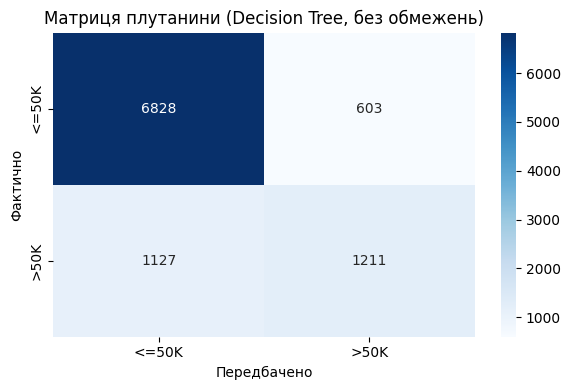

In [2]:
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)

train_acc = accuracy_score(y_train, dt_default.predict(X_train))
test_acc = accuracy_score(y_test, dt_default.predict(X_test))

print(f'Accuracy (train): {train_acc:.4f}')
print(f'Accuracy (test):  {test_acc:.4f}')
print(f'Overfitting gap:  {train_acc - test_acc:.4f}')
print(f'Глибина: {dt_default.get_depth()}, листків: {dt_default.get_n_leaves()}')
print()
print(classification_report(y_test, dt_default.predict(X_test),
                            target_names=['<=50K', '>50K']))

cm = confusion_matrix(y_test, dt_default.predict(X_test))
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
plt.xlabel('Передбачено')
plt.ylabel('Фактично')
plt.title('Матриця плутанини (Decision Tree, без обмежень)')
plt.tight_layout()
plt.show()

## 4.2. Візуалізація дерева

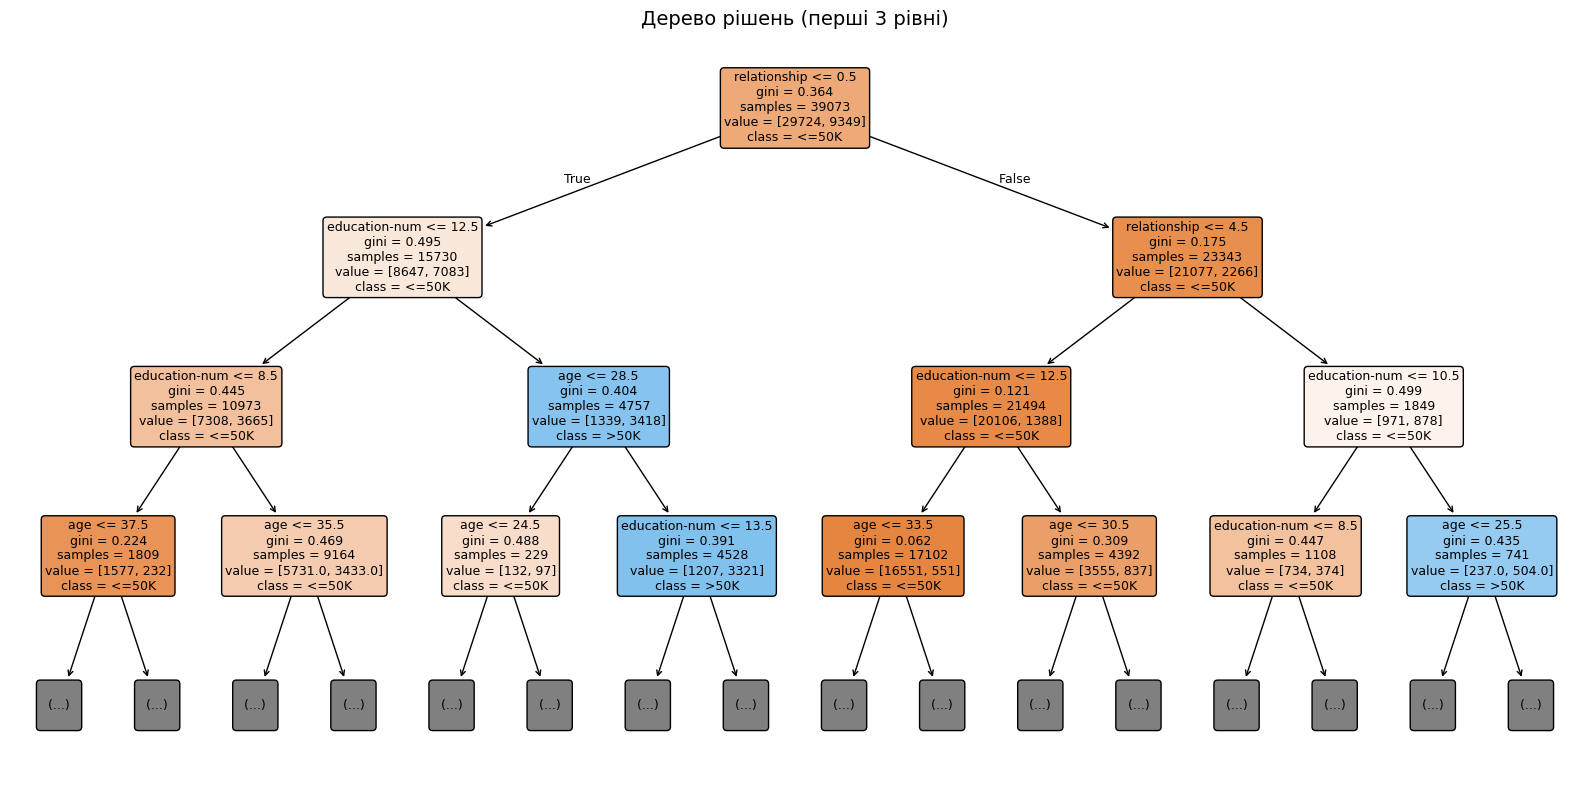

In [3]:
plt.figure(figsize=(16, 8))
plot_tree(dt_default, max_depth=3, filled=True, rounded=True,
          feature_names=['age', 'education-num', 'relationship'],
          class_names=['<=50K', '>50K'], fontsize=9)
plt.title('Дерево рішень (перші 3 рівні)', fontsize=14)
plt.tight_layout()
plt.show()

## 4.3. Важливість ознак

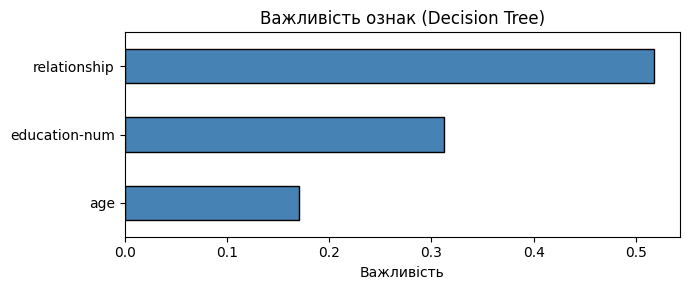

  age: 0.1709
  education-num: 0.3120
  relationship: 0.5171


In [4]:
importances = pd.Series(dt_default.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(7, 3))
importances.plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Важливість')
plt.title('Важливість ознак (Decision Tree)')
plt.tight_layout()
plt.show()

for name, imp in importances.items():
    print(f'  {name}: {imp:.4f}')

## 4.4. Підбір гіперпараметра max_depth

Порівняємо точність на train/test при різних значеннях глибини дерева, щоб виявити оптимальне значення та продемонструвати перенавчання.

max_depth  train_acc  test_acc     gap
        2     0.8139    0.8146 -0.0007
        3     0.8217    0.8236 -0.0020
        5     0.8249    0.8267 -0.0018
        7     0.8292    0.8289  0.0002
     None     0.8367    0.8229  0.0138


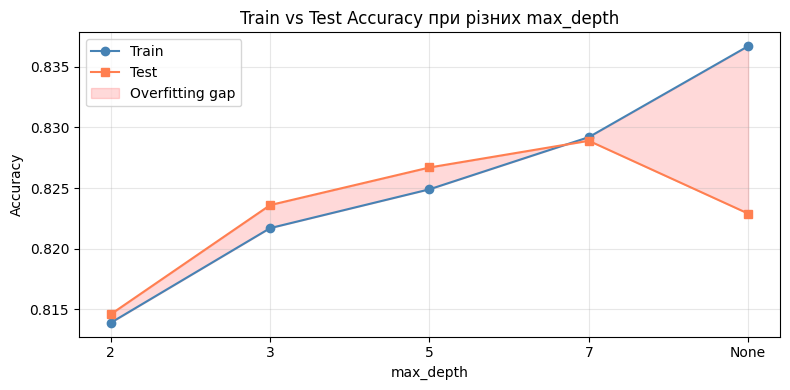

In [5]:
depths = [2, 3, 5, 7, None]
results = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    tr = accuracy_score(y_train, dt.predict(X_train))
    te = accuracy_score(y_test, dt.predict(X_test))
    results.append({'max_depth': str(d) if d else 'None',
                    'train_acc': round(tr, 4),
                    'test_acc': round(te, 4),
                    'gap': round(tr - te, 4)})

res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))

# Графік
x_labels = res_df['max_depth'].tolist()
x_pos = range(len(depths))

plt.figure(figsize=(8, 4))
plt.plot(x_pos, res_df['train_acc'], 'o-', label='Train', color='steelblue')
plt.plot(x_pos, res_df['test_acc'], 's-', label='Test', color='coral')
plt.fill_between(x_pos, res_df['train_acc'], res_df['test_acc'],
                 alpha=0.15, color='red', label='Overfitting gap')
plt.xticks(x_pos, x_labels)
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy при різних max_depth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4.5. Висновки

**Як дерево розбиває дані:**
- Перший розділ --- за ознакою `relationship` (одружені vs. ні), оскільки це найсильніший предиктор доходу.
- Далі --- `education-num` (рівень освіти), потім `age` (вік).
- Без обмеження глибини дерево перенавчається: train accuracy значно вища за test.
- Оптимальна глибина --- приблизно 3--5 рівнів.

**Примітка:** оскільки використовуються лише 3 ознаки, перенавчання менш виражене, ніж на повному наборі даних.

**Переваги:**
- Легко інтерпретувати та візуалізувати --- кожне рішення можна простежити.
- Не потребує нормалізації або масштабування ознак.

**Недоліки:**
- Схильне до перенавчання при великій глибині.
- Нестабільне --- невеликі зміни в даних можуть суттєво змінити структуру дерева.
- Жадібний алгоритм не гарантує глобально оптимального дерева.